<a href="https://colab.research.google.com/github/data4class/Teaching/blob/main/Deep_Learning_Demo_2_correlation_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time

def get_nifty500_symbols_and_industries(): # Ex: Make this function modular to get data for any Index.
    url = "https://archives.nseindia.com/content/indices/ind_nifty500list.csv"
    df = pd.read_csv(url)
    symbols = [f"{symbol}.NS" for symbol in df['Symbol'].tolist()]
    industries = df['Industry'].tolist()
    return symbols, industries

def download_data(symbols, years = 5):
    end_date = datetime.now()
    start_date = end_date - timedelta(days=years*365)  # 5 years ago
    all_data = {}
    for symbol in symbols[0:50]: # Remove indexing for full data
        try:
            stock = yf.Ticker(symbol)
            data = stock.history(start=start_date, end=end_date)
            # Ex: Remove securities other than Equity (EQ series)
            if not data.empty:
                all_data[symbol] = data['Close']
            else:
                print(f"No data available for {symbol}")
#            time.sleep(1)  # To avoid hitting rate limits
        except Exception as e:
            print(f"Error downloading data for {symbol}: {e}")

    return pd.DataFrame(all_data)

# Get the list of Nifty 500 symbols and industries
nifty500_symbols, _ = get_nifty500_symbols_and_industries()

# Download the data
print("Downloading data...")
df = download_data(nifty500_symbols, 2) #Increase number of years for better results

# Drop stocks with more than 5 days of missing data
max_allowed_missing = 5
columns_to_keep = df.columns[df.isna().sum() <= max_allowed_missing]
df_filtered = df[columns_to_keep]

# Fill remaining missing data using bfill
df_filled = df_filtered.bfill() # Ex: Use cubic spline to fill missing values.
0
# Compute daily returns
returns = df_filled.pct_change().dropna()


In [8]:
print(df_filled.head())

                            360ONE.NS    3MINDIA.NS       ABB.NS       ACC.NS  \
Date                                                                            
2023-10-10 00:00:00+05:30  500.429047  29832.472656  4138.877441  1972.635620   
2023-10-11 00:00:00+05:30  502.131348  30043.705078  4131.670898  2024.725952   
2023-10-12 00:00:00+05:30  497.267670  29951.927734  4161.927734  2015.638794   
2023-10-13 00:00:00+05:30  523.191345  29770.306641  4174.909180  1996.669678   
2023-10-16 00:00:00+05:30  538.025635  29580.955078  4226.488770  2016.929810   

                             AIAENG.NS  APLAPOLLO.NS   AUBANK.NS      AWL.NS  \
Date                                                                           
2023-10-10 00:00:00+05:30  3433.039062   1603.125488  713.191345  345.899994   
2023-10-11 00:00:00+05:30  3400.870361   1657.178467  713.739746  348.549988   
2023-10-12 00:00:00+05:30  3338.267578   1663.829712  714.288147  348.700012   
2023-10-13 00:00:00+05:30  3351.

In [9]:
print(df_filled.columns.tolist())

['360ONE.NS', '3MINDIA.NS', 'ABB.NS', 'ACC.NS', 'AIAENG.NS', 'APLAPOLLO.NS', 'AUBANK.NS', 'AWL.NS', 'AARTIIND.NS', 'AAVAS.NS', 'ABBOTINDIA.NS', 'ACE.NS', 'ADANIENT.NS', 'ADANIGREEN.NS', 'ADANIPORTS.NS', 'ADANIPOWER.NS', 'ATGL.NS', 'ABCAPITAL.NS', 'ABFRL.NS', 'ABREL.NS', 'ABSLAMC.NS', 'AFFLE.NS', 'AJANTPHARM.NS', 'AKZOINDIA.NS', 'APLLTD.NS', 'ALKEM.NS', 'ALKYLAMINE.NS', 'ALOKINDS.NS', 'AMBER.NS', 'AMBUJACEM.NS', 'ANANDRATHI.NS', 'ANANTRAJ.NS', 'ANGELONE.NS', 'APARINDS.NS', 'APOLLOHOSP.NS', 'APOLLOTYRE.NS', 'APTUS.NS', 'ASAHIINDIA.NS', 'ASHOKLEY.NS', 'ASIANPAINT.NS', 'ASTERDM.NS']


/tmp/ipython-input-1047293485.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stocks.fillna(method='bfill', inplace=True) # This is laready done above, no effect
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 248, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 124, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 124, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 124, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 5, 5)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,497 (99.60 KB)

 Trainable params: 25,497 (99.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step - loss: 0.1206 - mae: 0.2563 - val_loss: 0.0746 - val_mae: 0.2015
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 0.0958 - mae: 0.2246 - val_loss: 0.0446 - val_mae: 0.1486
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 0.0582 - mae: 0.1804 - val_loss: 0.0244 - val_mae: 0.1276
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0391 - mae: 0.1548 - val_loss: 0.0097 - val_mae: 0.0771
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0212 - mae: 0.1108 - val_loss: 0.0065 - val_mae: 0.0597
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0161 - mae: 0.0952 - val_loss: 0.0058 - val_mae: 0.0604
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0142 - mae: 0.0921 - val_loss: 0.0045 - val_mae: 0.0552
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - loss: 0.0129 - mae: 0.0851 - val_loss: 0.0036 - val_mae: 0.0478
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 0.0109 - mae: 

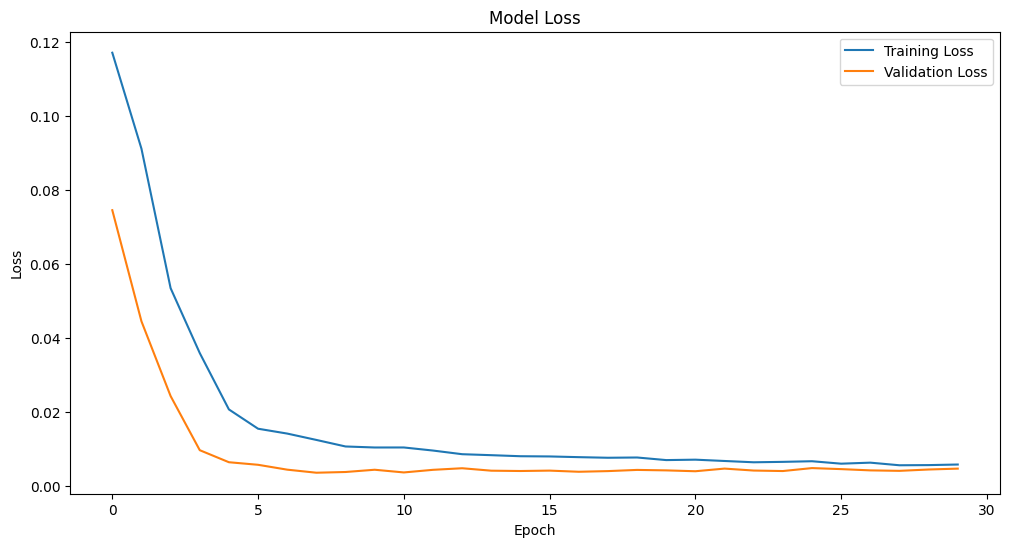

In [10]:
# Importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Flatten, Reshape, TimeDistributed, Conv2D, MaxPooling2D, Conv1D, MaxPooling1D
import matplotlib.pyplot as plt
%matplotlib inline

# Data from ProwessIQ for 22 Years
#!wget -O nifty_data.csv https://drive.google.com/uc?id=1rTI-ZcI2PiwGSKchh4krpzvcgUzUK-WW&export=download

#data = pd.read_csv('nifty_data.csv', parse_dates={'dt':['Slot Date']}, index_col='dt', na_values=[' '],dtype=np.float64)
data = df_filled.copy()
# Those stocks those are present in NIFTY50 ever since 2000.
stocks_of_interest = []
for col in data.columns: # This is already done above, so no effect
  if data[col].isna().sum() < 7:
    stocks_of_interest.append(col)

stocks = data[stocks_of_interest].copy()
stocks.fillna(method='bfill', inplace=True) # This is laready done above, no effect
stocks_daily_return = stocks.pct_change()
stocks_daily_return.dropna(inplace=True)

# Our portfolio choice (now with 5 stocks)
#p = ['Apollo Hospitals Enterprise Ltd.', 'Shree Cement Ltd.', 'Dr. Reddy\'S Laboratories Ltd.', 'State Bank Of India', 'Wipro Ltd.']
p = ['ASIANPAINT.NS', 'ABCAPITAL.NS', 'ADANIPOWER.NS', 'ALOKINDS.NS', 'AMBUJACEM.NS']
portfolio = stocks_daily_return[p].copy()
portfolio_closing = stocks[p].iloc[1:].copy()

# Ex: Instead of a specific portfolio, you can consider entire market portfolio.

# Data preparation for model
X_temp = []
y_temp = []
days = 250
d = portfolio.shape[0]
for n in range(d-days+1):
  r_x = portfolio.iloc[n:n+days].values # [0: 250] 250 days
  r_y = portfolio.iloc[n+1:n+days+1].values # [1: 251] 250 days
  c = np.cov(r_y.T) # Var-Covar for 251th day
  X_temp.append(r_x)
  y_temp.append(c*1000)
X = np.array(X_temp)
y = np.array(y_temp)

# Splititng data into train and test
X_train = X[:round(X.shape[0]*0.8)].copy()
y_train = y[:round(X.shape[0]*0.8)].copy()
X_test = X[round(X.shape[0]*0.8):].copy()
y_test = y[round(X.shape[0]*0.8):].copy()

# CNN + RNN + DNN model
model_cnn_lstm = Sequential()
model_cnn_lstm.add(Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model_cnn_lstm.add(MaxPooling1D(pool_size=2))
model_cnn_lstm.add(LSTM(units = 32, return_sequences = True))
model_cnn_lstm.add(Dropout(0.2))
model_cnn_lstm.add(LSTM(units = 32, return_sequences = False))
model_cnn_lstm.add(Dropout(0.2))
model_cnn_lstm.add(Dense(64, activation=tf.keras.activations.tanh))
model_cnn_lstm.add(Dropout(0.2))
model_cnn_lstm.add(Dense((y.shape[1]*y.shape[2])))
model_cnn_lstm.add(Reshape((y.shape[1], y.shape[2])))
model_cnn_lstm.summary()

model_cnn_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_cnn_lstm = model_cnn_lstm.fit(X_train, y_train, epochs=30, validation_split=0.2)

model_cnn_lstm.evaluate(X_test, y_test)

print(f'\nPredicted:\n{model_cnn_lstm.predict(X_test[-1:])}')
print(f'\nActual:\n{y_test[-1:]}')

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history_cnn_lstm.history['loss'], label='Training Loss')
plt.plot(history_cnn_lstm.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
print(stocks_daily_return.columns.tolist())